# 08 · E1d: which experiments would make the ladder decisive?

**Where we are.** Single-neuron optogenetic stimulation of the atlas kind constrains only a few parameter combinations: about 20 of 1,961 for the real fitted L1, and 24–68 for synthetic worms (Notebook 07). The deeper mechanisms' parameters (adaptation, regenerative currents, peptide release, homeostasis) are essentially unconstrained. Neither time courses (Notebook 06) nor better estimators (Notebook 07) can add information the experiment does not contain. So E1's verdict on amplitude data is a bracket, **L0 ≤ closed ≤ L1**, and the deeper levels remain *unidentifiable*, not *excluded*.

**The constructive question:** which *new interventions* would constrain the missing mechanisms, and is the gain large enough to make the closure ladder decisive? This turns E1's limitation into concrete, quantified experiment requests.

| design | what changes (same stimulated neurons, imaging coverage and trial count) | target |
|---|---|---|
| `repeat` | more trials of the atlas protocol | control |
| `strong` / `weak` | 3× / 0.3× stimulus amplitude | thresholds, nonlinearity |
| `train` | three 1-s pulses, 4 s apart | adaptation, slow accumulation |
| `long` | one 5-s pulse | adaptation, slow currents |
| `pairs` | two neurons stimulated together | interactions |
| `gapless` | atlas protocol in a gap-junction mutant (unc-7/unc-9-like) | electrical vs chemical routes |
| `unc31` | atlas protocol in unc-31 | peptide channel |

* **§1 Screening.** The Bayesian information gain of each design, given the atlas data already collected, in total and per mechanism. This uses the Fisher information at the truth of synthetic worms L2, L3 and L4.
* **§2 Validation.** Synthetic worms recorded with the atlas plus the best design: is their true level now *needed* (necessity rule), not merely not excluded? The control is atlas plus `repeat`, at the same trial budget.
* **§3 Real data.** Which design would best constrain the real fitted L1?

In [1]:
#@title Setup — run first (works locally on a Mac/PC and on Colab)
import os, sys, subprocess
REPO_URL   = "https://github.com/aslansd/Closure-Bench.git"  # Colab only: clone from here
DRIVE_PATH = "/content/drive/MyDrive/Closure-Bench"          # Colab only: ...or use a Drive copy
IN_COLAB = "google.colab" in sys.modules

def _find_package():
    # 1) explicit location, 2) the repo this notebook lives in, 3) Colab clone / Drive
    cands = [os.environ.get("CLOSUREBENCH_ROOT", ""), ".", "..", "/content/Closure-Bench", DRIVE_PATH]
    for root in cands:
        if root and os.path.isdir(os.path.join(root, "closurebench")):
            return os.path.abspath(root)
    if IN_COLAB:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "wormneuroatlas", "optax"], check=False)
        if subprocess.run(["git", "clone", "-q", REPO_URL, "/content/Closure-Bench"]).returncode == 0:
            return "/content/Closure-Bench"
        from google.colab import drive
        drive.mount("/content/drive")
        if os.path.isdir(os.path.join(DRIVE_PATH, "closurebench")):
            return DRIVE_PATH
    raise RuntimeError("closurebench not found. Locally: open this notebook from Closure-Bench/notebooks/, "
                       "or set the environment variable CLOSUREBENCH_ROOT to the Closure-Bench folder.")

ROOT = _find_package()
sys.path.insert(0, ROOT)
try:
    import jax, optax, wormneuroatlas  # noqa: F401
except ImportError as e:
    raise ImportError(f"{e}. Locally, create the environment first: see README.md "
                      "('Run locally'), then select the 'Python (closurebench)' kernel.") from None
RESULTS = os.environ.get("CLOSUREBENCH_RESULTS", os.path.join(ROOT, "results"))
os.makedirs(RESULTS, exist_ok=True)
from closurebench import config as CBC
MODE = CBC.get_mode()        # 'smoke' | 'laptop' | 'full'  (env CLOSUREBENCH_MODE, default: full on GPU, laptop on CPU)
print("closurebench:", ROOT); print("results:", RESULTS); print(CBC.describe_machine()); print("MODE:", MODE)

closurebench: /Users/asataryd/Documents/ENI-Projects/Aslan/NeuroAILab/Githubs/Closure-Bench-Mac
results: /Users/asataryd/Documents/ENI-Projects/Aslan/NeuroAILab/Githubs/Closure-Bench-Mac/results
Darwin arm64 | python 3.11.5 | jax 0.10.2 on cpu (cpu) | CPU cores: 8
MODE: laptop


In [2]:
import json, time, datetime, numpy as np, matplotlib.pyplot as plt, jax, jax.numpy as jnp
import closurebench
assert tuple(int(x) for x in closurebench.__version__.split(".")[:2]) >= (0, 7), \
    f"Notebook 08 needs closurebench >= 0.7 (found {closurebench.__version__}); copy the full package and restart the kernel"
from closurebench import data as D, ladder as lad, metrics as M, design as DZ
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
CONF = {
    "smoke":  dict(N_NEURONS=16,  REAL_WIRING=False, SCREEN_TRUTHS=["L2"], DESIGNS=["repeat", "long", "strong"],
                   VAL_TRUTHS=["L2"], K=2, STEPS=15, N_BOOT=100, REAL_SCREEN=False),
    "laptop": dict(N_NEURONS=60,  REAL_WIRING=True,  SCREEN_TRUTHS=["L2", "L3", "L4"], DESIGNS=list(DZ.DESIGNS),
                   VAL_TRUTHS=["L2", "L3"], K=3, STEPS=250, N_BOOT=1000, REAL_SCREEN=True),
    "full":   dict(N_NEURONS=120, REAL_WIRING=True,  SCREEN_TRUTHS=["L2", "L3", "L4"], DESIGNS=list(DZ.DESIGNS),
                   VAL_TRUTHS=["L2", "L3", "L4"], K=5, STEPS=500, N_BOOT=2000, REAL_SCREEN=True),
}[MODE]
globals().update(CONF)
SEED, TRIALS, PEPTIDE_SCALE = 1, 3, 0.5
LADDER = ["L0", "L1", "L2", "L3", "L4"]          # B is excluded: it cannot represent stimulus protocols
TARGET = {"L2": ["gK", "gCa", "th_w", "th_ca", "tau_w"], "L3": ["rec", "rel", "tau_p"], "L4": ["eta", "rho", "tau_h"]}
TAG = "" if MODE == "full" else f"_{MODE}"
cfg = lad.SimConfig()
ds_path = os.path.join(RESULTS, "atlas_dataset.npz")
real = D.Dataset.load(ds_path) if os.path.exists(ds_path) else D.load_atlas_dataset()
if REAL_WIRING:
    mk = real.mask()[0]; score = mk.sum(1).astype(float); score[real.stim] += mk.sum(0)
    template = D.subset(real, np.sort(np.argsort(-score)[:N_NEURONS]))
else:
    template = lad.random_wiring(N=N_NEURONS, seed=0, trials=4)
st = lad.Structure.from_dataset(template)
print(template.summary())

Dataset: N=60 neurons, S=60 stimulated neurons, strains=('wt', 'unc31')
  chemical synapses: 280  gap-junction pairs: 98  peptidergic pairs: 2214
  signs: +49 / -51 / unknown 181 (on existing synapses)
  wt: 3534 observed pairs, median trials 10
  unc31: 2401 observed pairs, median trials 2


## 1 · Screening: information gain per design

For each synthetic truth and design, the gain in bits is computed for all mechanism parameters together and for each mechanism. The atlas data already collected are the baseline, and per-stimulus efficacies are treated as nuisance parameters. The prior is N(0, 1) on each unconstrained parameter.

In [3]:
screen = {}
for truth in SCREEN_TRUTHS:
    syn, p_true, _ = lad.make_synthetic(template, true_level=truth, seed=SEED, peptide_scale=PEPTIDE_SCALE)
    print(f"truth {truth} (per-trial noise sd {syn.meta['noise_sd']:.4f}):")
    t0 = time.time()
    screen[truth] = DZ.score_designs(truth, p_true, syn, st, cfg, noise_sd=syn.meta["noise_sd"], designs=DESIGNS, trials=TRIALS)
    print(f"  ({(time.time() - t0) / 60:.1f} min)")
def target_ig(truth, kind):
    g = screen[truth][kind]["ig"]; return sum(g.get(x, 0.0) for x in TARGET[truth])
print(f"\n{'design':8s} " + " ".join(f"{t + ' target':>11s}" for t in SCREEN_TRUTHS) + "   (bits on the truth's own mechanism)")
for kind in DESIGNS:
    print(f"{kind:8s} " + " ".join(f"{target_ig(t, kind):11.1f}" for t in SCREEN_TRUTHS))

truth L2 (per-trial noise sd 0.0007):
  repeat   IG total     45.7 bits | stiff directions 65 -> 71
  strong   IG total    194.5 bits | stiff directions 65 -> 84
  weak     IG total     24.9 bits | stiff directions 65 -> 67
  train    IG total    206.1 bits | stiff directions 65 -> 87
  long     IG total    333.4 bits | stiff directions 65 -> 102
  pairs    IG total    104.5 bits | stiff directions 65 -> 73
  gapless  IG total     95.5 bits | stiff directions 65 -> 72
  unc31    IG total     45.7 bits | stiff directions 65 -> 71
  (0.9 min)
truth L3 (per-trial noise sd 0.0007):
  repeat   IG total     49.7 bits | stiff directions 88 -> 96
  strong   IG total    201.6 bits | stiff directions 88 -> 116
  weak     IG total     18.9 bits | stiff directions 88 -> 89
  train    IG total    224.5 bits | stiff directions 88 -> 124
  long     IG total    360.4 bits | stiff directions 88 -> 141
  pairs    IG total    107.5 bits | stiff directions 88 -> 100
  gapless  IG total     99.7 bits | sti

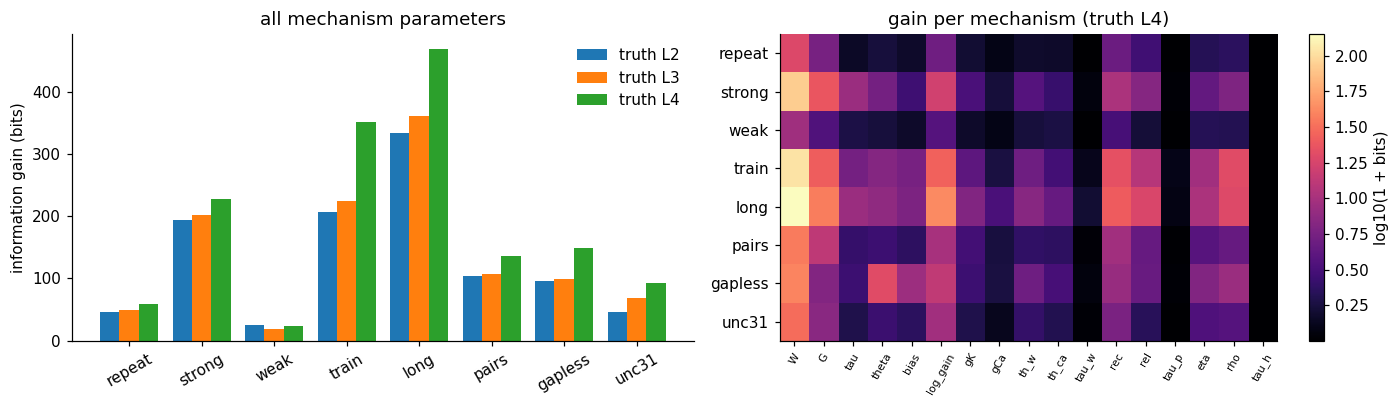

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(13, 3.8))
x = np.arange(len(DESIGNS)); wbar = 0.8 / len(SCREEN_TRUTHS)
for k, t in enumerate(SCREEN_TRUTHS):
    ax[0].bar(x + k * wbar, [screen[t][d]["ig"]["total"] for d in DESIGNS], wbar, label=f"truth {t}")
ax[0].set_xticks(x + wbar * (len(SCREEN_TRUTHS) - 1) / 2); ax[0].set_xticklabels(DESIGNS, rotation=30)
ax[0].set_ylabel("information gain (bits)"); ax[0].set_title("all mechanism parameters"); ax[0].legend(frameon=False)
t_last = SCREEN_TRUTHS[-1]
groups = [g for g in ["W", "G", "tau", "theta", "bias", "log_gain"] + sum(TARGET.values(), []) if g in screen[t_last][DESIGNS[0]]["ig"]]
mat = np.array([[screen[t_last][d]["ig"].get(g, np.nan) for g in groups] for d in DESIGNS])
im = ax[1].imshow(np.log10(1 + mat), aspect="auto", cmap="magma")
ax[1].set_xticks(range(len(groups))); ax[1].set_xticklabels(groups, rotation=60, fontsize=7)
ax[1].set_yticks(range(len(DESIGNS))); ax[1].set_yticklabels(DESIGNS)
plt.colorbar(im, ax=ax[1], label="log10(1 + bits)"); ax[1].set_title(f"gain per mechanism (truth {t_last})")
plt.tight_layout(); plt.show()

## 2 · Validation: does the best design make the true level *necessary*?

The design chosen for each truth is the one with the largest information gain on that truth's own mechanism, determined by §1 before any fitting. It is compared with `repeat`, which adds the same number of trials of the atlas protocol. Both use the same synthetic worm (same parameters, same per-trial noise).

**Pre-registered rule.** A design makes truth T detectable if, with the atlas plus that design, both hold:
* the necessity rule gives **L_needed = T** (T beats every shallower rung significantly);
* the sufficiency rule gives **L* = T**.

The control is expected to fail this rule, as in Notebooks 02, 06 and 07.

In [5]:
CHOSEN = {t: max(DESIGNS, key=lambda d: target_ig(t, d)) for t in VAL_TRUTHS}
VAL_DESIGNS = {t: list(dict.fromkeys(["repeat", CHOSEN[t]])) for t in VAL_TRUTHS}
prereg = os.path.join(RESULTS, f"E1d_preregistration{TAG}.json")
plan = {"experiment": "E1d experimental design (synthetic validation)", "mode": MODE,
        "registered_at": datetime.datetime.now(datetime.timezone.utc).isoformat(), "config": CONF,
        "chosen_design": CHOSEN, "control": "repeat",
        "success_rule": "with atlas + design: L_needed (necessity) == truth AND L* (sufficiency) == truth",
        "screening_target_bits": {t: {d: target_ig(t, d) for d in DESIGNS} for t in VAL_TRUTHS if t in screen}}
if os.path.exists(prereg):
    old = json.load(open(prereg)); assert old["chosen_design"] == CHOSEN, "screening changed since registration: inspect before proceeding"
    plan = old; print("Existing registration (", plan["registered_at"], ") used unchanged.")
else:
    json.dump(plan, open(prereg, "w"), indent=2); print("Registered ->", prereg)
print("chosen designs:", CHOSEN)

Registered -> /Users/asataryd/Documents/ENI-Projects/Aslan/NeuroAILab/Githubs/Closure-Bench-Mac/results/E1d_preregistration_laptop.json
chosen designs: {'L2': 'long', 'L3': 'long'}


In [6]:
val = {}
for truth in VAL_TRUTHS:
    base, _, _ = lad.make_synthetic(template, true_level=truth, seed=SEED, peptide_scale=PEPTIDE_SCALE)
    noise = base.meta["noise_sd"]                     # the atlas's per-trial noise, kept fixed for every design
    for kind in VAL_DESIGNS[truth]:
        t0 = time.time()
        C = DZ.combine(template, DZ.design_columns(template, kind, trials=TRIALS))
        ds, _, _ = lad.make_synthetic(C, true_level=truth, seed=SEED, peptide_scale=PEPTIDE_SCALE, noise_sd=noise)
        ck = os.path.join(RESULTS, "e1d_validation_ck", MODE, f"{truth}_s{SEED}_{kind}")
        preds, _, dl = M.run_crossvalidated_ladder(ds, levels=LADDER, k=K, steps=STEPS, lr=2e-2, cfg=cfg,
                                                   equal_budget=True, restarts=3, checkpoint=ck, log=None)
        pt, bt = M.bootstrap_feve(preds, ds, LADDER, n_boot=N_BOOT)
        dec, nec = M.closure_decision(pt, bt, ladder=tuple(LADDER), blackbox=None), M.necessity(pt, bt, ladder=tuple(LADDER))
        val[(truth, kind)] = dict(point=pt, L_star=dec["L_star"], L_needed=nec["L_needed"], nec=nec)
        ok = dec["L_star"] == truth and nec["L_needed"] == truth
        print(f"truth {truth} + {kind:8s}: L* = {dec['L_star']}, L_needed = {nec['L_needed']}  -> detectable: {ok}   "
              f"FEVE " + " ".join(f"{L}={pt[L]:.3f}" for L in LADDER) + f"  ({(time.time() - t0) / 60:.0f} min)")

truth L2 + repeat  : L* = L1, L_needed = L3  -> detectable: False   FEVE L0=0.664 L1=0.959 L2=0.967 L3=0.969 L4=0.969  (17 min)
truth L2 + long    : L* = L1, L_needed = L2  -> detectable: False   FEVE L0=0.697 L1=0.953 L2=0.959 L3=0.960 L4=0.960  (17 min)
truth L3 + repeat  : L* = L2, L_needed = L3  -> detectable: False   FEVE L0=0.618 L1=0.944 L2=0.948 L3=0.965 L4=0.966  (16 min)
truth L3 + long    : L* = L3, L_needed = L2  -> detectable: False   FEVE L0=0.750 L1=0.934 L2=0.948 L3=0.956 L4=0.956  (17 min)


--- truth L2, atlas + repeat
rung   gain over best shallower rung [95% CI]   needed?
L1     +0.307 [+0.220, +0.466]               yes
L2     +0.009 [+0.003, +0.019]               yes
L3     +0.002 [+0.000, +0.006]               yes
L4     -0.000 [-0.001, -0.000]               no
=> deepest needed rung L_needed = L3
--- truth L2, atlas + long
rung   gain over best shallower rung [95% CI]   needed?
L1     +0.325 [+0.176, +0.651]               yes
L2     +0.008 [+0.003, +0.022]               yes
L3     +0.003 [-0.000, +0.009]               no
L4     -0.000 [-0.001, +0.000]               no
=> deepest needed rung L_needed = L2
--- truth L3, atlas + repeat
rung   gain over best shallower rung [95% CI]   needed?
L1     +0.345 [+0.227, +0.567]               yes
L2     +0.005 [+0.002, +0.011]               yes
L3     +0.019 [+0.006, +0.044]               yes
L4     +0.001 [-0.001, +0.005]               no
=> deepest needed rung L_needed = L3
--- truth L3, atlas + long
rung   gain over best sha

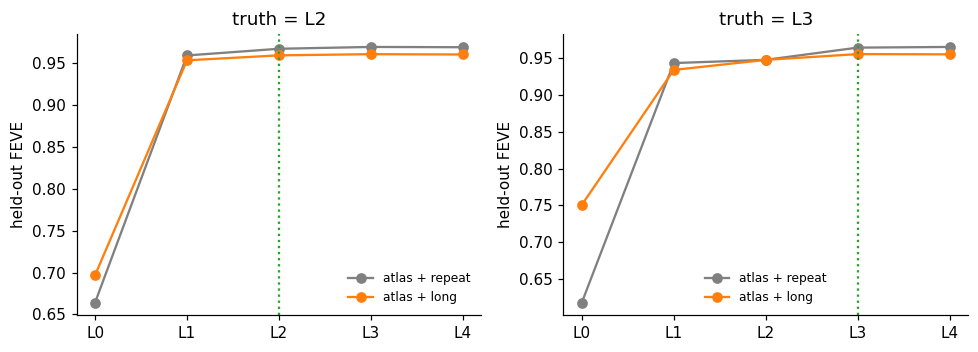

In [7]:
for truth in VAL_TRUTHS:
    for kind in VAL_DESIGNS[truth]:
        print(f"--- truth {truth}, atlas + {kind}"); print(M.format_necessity(val[(truth, kind)]["nec"]))
verdict = {t: {k: bool(val[(t, k)]["L_star"] == t and val[(t, k)]["L_needed"] == t) for k in VAL_DESIGNS[t]} for t in VAL_TRUTHS}
print("\nRegistered rule -> detectable:", json.dumps(verdict))
fig, axes = plt.subplots(1, len(VAL_TRUTHS), figsize=(4.5 * len(VAL_TRUTHS), 3.3), squeeze=False)
for ax, t in zip(axes[0], VAL_TRUTHS):
    for kind, c in zip(VAL_DESIGNS[t], ["0.5", "tab:orange"]):
        ax.plot(range(5), [val[(t, kind)]["point"][L] for L in LADDER], "o-", c=c, label=f"atlas + {kind}")
    ax.axvline(LADDER.index(t), ls=":", c="tab:green"); ax.set_xticks(range(5)); ax.set_xticklabels(LADDER)
    ax.set_title(f"truth = {t}"); ax.set_ylabel("held-out FEVE"); ax.legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

## 3 · Real data: which experiment would best constrain the worm's fitted L1?

The same screening, now for the real fitted L1: Notebook 04's fold-1 model on the 120-neuron network, with the atlas's own coverage and its pooled per-trial noise. This asks which new experiment would most sharpen the real network's wiring-level description. It cannot rank designs for the deeper mechanisms, because the real model has none.

In [8]:
import pickle
real_screen = None
e1_path = os.path.join(RESULTS, "E1_result_laptop.json")
if REAL_SCREEN and os.path.exists(e1_path):
    c = json.load(open(os.path.join(RESULTS, json.load(open(e1_path))["preregistration"])))["config"]
    ds_r = real
    if c["n_neurons"] < ds_r.N:
        mk = ds_r.mask()[0]; score = mk.sum(1).astype(float); score[ds_r.stim] += mk.sum(0)
        ds_r = D.subset(ds_r, np.sort(np.argsort(-score)[:c["n_neurons"]]))
    st_r = lad.Structure.from_dataset(ds_r, tie=c["tie_classes"])
    p_r = pickle.load(open(os.path.join(RESULTS, "e1_checkpoints_laptop", "fold0_L1_final.pkl"), "rb"))["params"]
    p_r = {k: v for k, v in p_r.items() if k != "stim_col"}           # efficacies are re-estimated as nuisance
    m2 = ds_r.n[0] >= 2
    noise_r = float(np.sqrt(np.mean((ds_r.var_mean[0] * ds_r.n[0])[m2])))
    print(f"real per-trial noise sd {noise_r:.3f}"); t0 = time.time()
    real_screen = DZ.score_designs("L1", p_r, ds_r, st_r, lad.SimConfig(**c["sim"]), noise_sd=noise_r, designs=DESIGNS, trials=TRIALS)
    print(f"({(time.time() - t0) / 60:.0f} min)")
    print(f"\n{'design':8s} {'total':>8s} " + " ".join(f"{g:>8s}" for g in ["W", "G", "tau", "theta", "bias"]))
    for d in DESIGNS:
        g = real_screen[d]["ig"]
        print(f"{d:8s} {g['total']:8.1f} " + " ".join(f"{g.get(x, 0):8.1f}" for x in ["W", "G", "tau", "theta", "bias"]))
else:
    print("skipped (smoke mode or Notebook 04 laptop results missing)")

real per-trial noise sd 0.122
  repeat   IG total    175.9 bits | stiff directions 17 -> 24
  strong   IG total    344.9 bits | stiff directions 17 -> 29
  weak     IG total     63.0 bits | stiff directions 17 -> 19
  train    IG total    659.7 bits | stiff directions 17 -> 49
  long     IG total    834.6 bits | stiff directions 17 -> 61
  pairs    IG total    293.2 bits | stiff directions 17 -> 29
  gapless  IG total    221.2 bits | stiff directions 17 -> 23
  unc31    IG total    175.9 bits | stiff directions 17 -> 24
(8 min)

design      total        W        G      tau    theta     bias
repeat      175.9    131.3      1.4      0.2      1.7      1.0
strong      344.9    245.0      7.9      1.7      3.8      2.3
weak         63.0     48.5      0.4      0.4      1.1      0.8
train       659.7    499.3      8.8      1.1      5.8      3.4
long        834.6    619.7     17.8      3.5      7.9      4.6
pairs       293.2    211.6      2.5      0.4      2.8      1.6
gapless     221.2    156

In [9]:
out = {"screen": screen, "chosen": CHOSEN,
       "validation": {f"{t}+{k}": {kk: v for kk, v in r.items() if kk != "nec"} | {"necessity": r["nec"]["table"]} for (t, k), r in val.items()},
       "verdict": verdict, "real_screen": real_screen}
json.dump(out, open(os.path.join(RESULTS, f"E1d_result{TAG}.json"), "w"), indent=2, default=float)
print("saved", f"E1d_result{TAG}.json")

saved E1d_result_laptop.json


### Results of the `laptop` run (2026-10-07; 60-neuron real wiring, one seed; real L1 on 120 neurons)

**§1 Screening: a 5-second pulse is the most informative single change to the atlas protocol, for every model tested.**

| design | L2 worm | L3 worm | L4 worm | real L1 | real L1: stiff directions (from 17) |
|---|---|---|---|---|---|
| repeat (control) | 46 bits | 50 | 59 | 176 | 24 |
| strong (3×) | 195 | 202 | 227 | 345 | 29 |
| train | 206 | 225 | 352 | 660 | 49 |
| **long (5 s)** | **333** | **360** | **469** | **835** | **61** |
| pairs | 105 | 108 | 136 | 293 | 29 |
| gapless | 96 | 100 | 149 | 221 | 23 |
| unc31 | 46 | 69 | 92 | 176 | 24 |

* **Sanity checks pass.** For the L2 worm and the real L1, which have no peptide channel, `unc31` adds exactly what `repeat` adds.
* **Per mechanism,** `long` gives the largest gain on each truth's own mechanism (L2: 15 bits vs 1.7 for `repeat`; L3: 34 vs 4.8; L4: 28 vs 2.4), with `train` close for L4. `gapless` is the best design for thresholds (θ: 12.9 bits on the real L1).

**§2 Validation: the registered rule fails in all four cases.**

| truth + design | L* (sufficient) | L_needed | true level's gain over best shallower [95% CI] |
|---|---|---|---|
| L2 + repeat | L1 | L3 ✗ (too deep) | +0.009 [+0.003, +0.019] |
| L2 + long | L1 | **L2 ✓** | +0.008 [+0.003, +0.022] |
| L3 + repeat | L2 | **L3 ✓** | +0.019 [+0.006, +0.044] |
| L3 + long | **L3 ✓** | L2 | +0.013 [−0.018, +0.066] |

**Why both rules fail.**

1. **The deeper mechanisms are small effects.** In these synthetic worms they add only 0.008–0.019 FEVE over L1, which alone reaches 0.93–0.96. The sufficiency rule's 5% threshold is far larger, so it accepts a shallower level whenever the true level's advantage is real but small.
2. **The necessity rule has no minimum effect size.** With precise data, a +0.002 gain whose CI excludes zero counts as "needed" (L2 + repeat → L3). This can even invert the bracket (L_needed = L3 above L* = L1).

The two rules answer different questions, one practical (is the gain ≥ 5%?) and one statistical (is it > 0?), and neither is calibrated to the size of the effects being tested.

**What this does and does not show.** With one seed per case, `long` did not improve recovery over `repeat`: the necessity rule was right once for each. The screening result (far more information, especially on the real L1) stands on its own. The claim "with this experiment, E1 decides L2/L3" is **not** supported yet.

**Next step (Notebook 09).** Replace the two thresholds with one **null-calibrated rule**: a level counts as needed only if its gain over every shallower level exceeds a threshold δ, set from synthetic worms in which that level is *not* present. Then measure recovery rates on separate test worms with several seeds.

## 4 · Reading the result

| outcome | consequence |
|---|---|
| best design detectable, `repeat` not | **Request that experiment.** The ladder can decide the deeper levels once it exists. The screening table gives the expected gain per mechanism, which is the argument for the experiment. |
| neither detectable, but the best design raises information substantially ← **this run** | The experiment helps but is not enough on its own, and the decision rules themselves need calibration to the effect sizes (see results above). |
| neither detectable, and the gain is small | Interventions of this family cannot identify the deeper mechanisms. The closed level stays a bracket, and the next lever is a different kind of measurement (e.g. spontaneous whole-brain activity, Atanas et al. 2023). |

**For the proposal.** E1's original design asks whether a closed level *exists*. The analysis here adds a prior question that any such test must answer: *what experiment can see the difference between the levels?* Expressing closure tests as information budgets makes the program auditable. A claim of closure at level L is only as strong as the information the experiment carried about the levels above L.